# Gate drivers session

Dead time, arm, duty, the gate snapshot, a burst.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


`device.gates` is the arming policy, one of it. `check()` re-reads BDTR DTG and refuses a stage with no dead time; the 2EDL8034 has no interlock of its own.

In [3]:
stage = device.gates
print('dead time:', stage.dead_time())
print('check:', {k: stage.check()[k] for k in ('deadtime', 'deadtime_ns', 'period', 'gate_shorts')})
for name, volts, ok, want in stage.interlock():
    print('%-8s %-8s ok=%s want=%s' % (name, volts, ok, want))

dead time: {'nanoseconds': 79, 'skew': 0, 'floor': 5}
check: {'deadtime': 19, 'deadtime_ns': 79, 'period': 2376, 'gate_shorts': ()}
AFE_ON   None     ok=False want=None


The unmodified bench board reads Cinj 0.77 V and Clevel 0.06 V against 3 V each, and its break input is latched: `bypass_sto=True, ignore_interlock=True` is what arms it. Both are decisions, which is why neither is silent.

In [4]:
armed = stage.arm(bypass_sto=True, ignore_interlock=True)
print('pwm_enabled', armed['pwm_enabled'], 'fault', armed['fault'],
      'break_bypassed', armed['break_bypassed'])

pwm_enabled True fault False break_bypassed True


A duty is ticks against `period`. With a period count the update ISR zeroes the compares after exactly that many periods: 500 is 10.000 ms at 50 kHz, where a link-timed hold was 93 to 108 ms (MINOR 8).

In [5]:
gd = device.gate_drivers
period = gd.state()['period']
tenth = (period - 1) // 10
gd.duty((tenth, 0, 0), periods=500)
snap = gd.state()
for key in ('period', 'deadtime', 'deadtime_ns', 'duty', 'requested_ticks',
            'pins', 'pins_at', 'periods_left', 'updates', 'overruns',
            'keepalive', 'worst_gap_cycles', 'gate_shorts', 'break_bypassed',
            'dcbus_raw', 'ntc_raw'):
    print('%-16s %s' % (key, snap.get(key, 'not in this reply')))

period           2376
deadtime         19
deadtime_ns      79
duty             (237, 0, 0)
requested_ticks  (237.0, 0.0, 0.0)
pins             {'UL': False, 'UH': True, 'VL': True, 'VH': False, 'WL': True, 'WH': False}
pins_at          184
periods_left     498
updates          0
overruns         0
keepalive        1712000
worst_gap_cycles 24700
gate_shorts      ()
break_bypassed   True
dcbus_raw        not in this reply
ntc_raw          not in this reply


The gate snapshot is one IDR load with TIM1->CNT beside it: six separate reads at 50 kHz could straddle an edge and show a leg with both FETs on, the one state dead time exists to prevent. Repeated reads land at different counts, so they walk the period.

In [6]:
import time

time.sleep(0.05)
print('periods_left after the hold:', gd.state()['periods_left'])
gd.duty((tenth, tenth, tenth))
snapshots = [gd.state() for _ in range(8)]
print()
print('  CNT   UL UH   VL VH   WL WH   both on?')
for s in snapshots:
    p = s['pins']
    both = [leg for leg in ('U', 'V', 'W') if p[leg + 'L'] and p[leg + 'H']]
    print('%5d %5d%3d%5d%3d%5d%3d   %s'
          % (s['pins_at'], p['UL'], p['UH'], p['VL'], p['VH'], p['WL'], p['WH'],
             ','.join(both) if both else 'no'))

periods_left after the hold: 0

  CNT   UL UH   VL VH   WL WH   both on?
 1418     1  0    1  0    1  0   no
 2035     1  0    1  0    1  0   no
  276     1  0    1  0    1  0   no
  893     1  0    1  0    1  0   no
 1510     1  0    1  0    1  0   no
 2127     1  0    1  0    1  0   no
  368     1  0    1  0    1  0   no
  985     1  0    1  0    1  0   no


A burst: every sweep the loop manages becomes a record until the ring is full, the pins riding the same records as the currents.

300 records, dropped 0


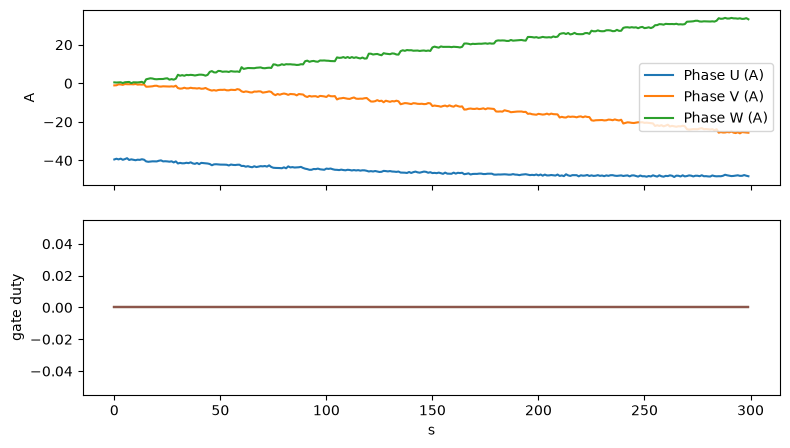

In [7]:
import matplotlib.pyplot as plt

daq = device.daq
daq.enable()
burst = daq.capture('phaseU', 'phaseV', 'phaseW', records=300)
print(len(burst), 'records, dropped', daq.state()['dropped'])
df = daq.frame(burst, index='elapsed', scaled=True)
fig, (top, bottom) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
df[[c for c in df.columns if c.endswith('(A)')]].plot(ax=top)
top.set_ylabel('A')
df[[c for c in df.columns if c.startswith('TIM1_CH')]].plot(ax=bottom, legend=False)
bottom.set_ylabel('gate duty')
bottom.set_xlabel('s')
plt.show()

In [8]:
gd.duty((0, 0, 0))
print(stage.disarm()['pwm_enabled'])
device.close()

False


## Conclusions

In [9]:
ticks = snap['duty'][0]
period = snap['period']
print('period           %d ticks = %.1f kHz centre-aligned' % (period, 237.5e6 / (2.0 * (period - 1)) / 1e3))
print('dead time        DTG %d = %d ns' % (snap['deadtime'], snap['deadtime_ns']))
print('duty asked       %d of %d ticks = %.1f %%' % (ticks, period - 1, 100.0 * ticks / (period - 1)))
print('counted hold     500 periods = %.3f ms' % (500.0 / 50e3 * 1e3))
print('gate shorts      %s' % (snap['gate_shorts'] or 'none'))
print('overruns         %d' % snap['overruns'])
print('keepalive        %d edges, worst gap %d cycles = %.1f us'
      % (snap['keepalive'], snap['worst_gap_cycles'], snap['worst_gap_cycles'] / 475.0))
walked = sorted(s['pins_at'] for s in snapshots)
both_on = sum(1 for s in snapshots for leg in ('U', 'V', 'W')
              if s['pins'][leg + 'L'] and s['pins'][leg + 'H'])
print('snapshots        %d reads, CNT %d to %d of %d'
      % (len(snapshots), walked[0], walked[-1], period))
print('both FETs on     %d of %d legs sampled' % (both_on, 3 * len(snapshots)))
print('burst            %d records, %d analog columns, %d pin columns'
      % (len(df), len([c for c in df.columns if c.endswith('(A)')]),
         len([c for c in df.columns if c.startswith('TIM1_CH')])))

period           2376 ticks = 50.0 kHz centre-aligned
dead time        DTG 19 = 79 ns
duty asked       237 of 2375 ticks = 10.0 %
counted hold     500 periods = 10.000 ms
gate shorts      none
overruns         0
keepalive        1712000 edges, worst gap 24700 cycles = 52.0 us
snapshots        8 reads, CNT 276 to 2127 of 2376
both FETs on     0 of 24 legs sampled
burst            300 records, 3 analog columns, 6 pin columns


A duty is ticks against `period`, and the compare write itself lands in about 15 ms - some 800 PWM cycles. That is why op 2 takes a period count: the update ISR zeroes the compares when it reaches zero, so 500 periods is 10.000 ms exactly, where a link-timed hold measured 93 to 108 ms at the FETs (FINDINGS).

`gate_shorts` is measured by the board, which drives one gate pin and watches the other sink through its own pull-down; it reads no legs while armed, because the probe needs the pins. The pins and the currents ride the same records, so every point on both is one window.